In [13]:
import shap
import joblib
from credit_scoring.models.pipeline import load_data, split_data
from credit_scoring.paths import PROJECT_ROOT

In [ ]:
X, y = load_data()
X_train, X_test, y_train, y_test = split_data(X, y)

In [3]:
pipeline = joblib.load(PROJECT_ROOT / "models/lgbm_pipeline.joblib")
clip_step = pipeline.named_steps["clip"]
model = pipeline.named_steps["model"]

In [4]:
X_test_clipped = clip_step.transform(X_test)

In [5]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_clipped)
print(shap_values.shape)# it has be (n_samples, n_features)

(29878, 10)


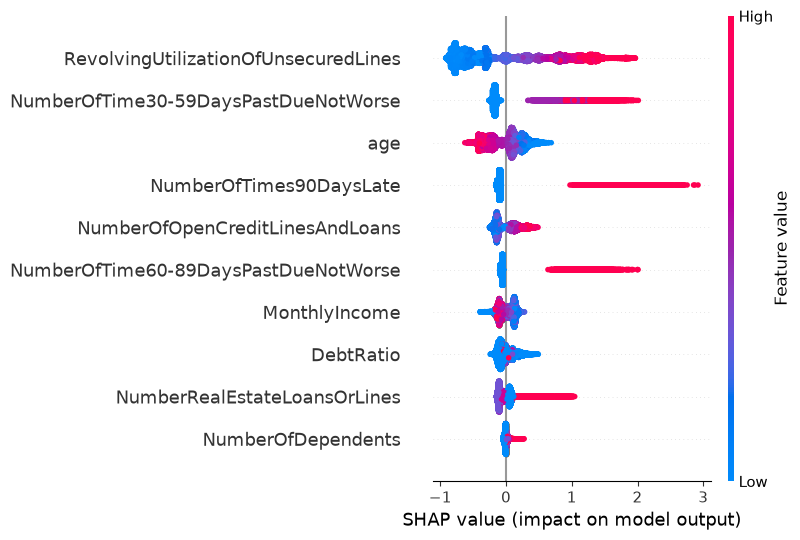

In [6]:
# Global importance — какие признаки в среднем важнее всего по всему test-датасету
shap.summary_plot(shap_values, X_test_clipped)

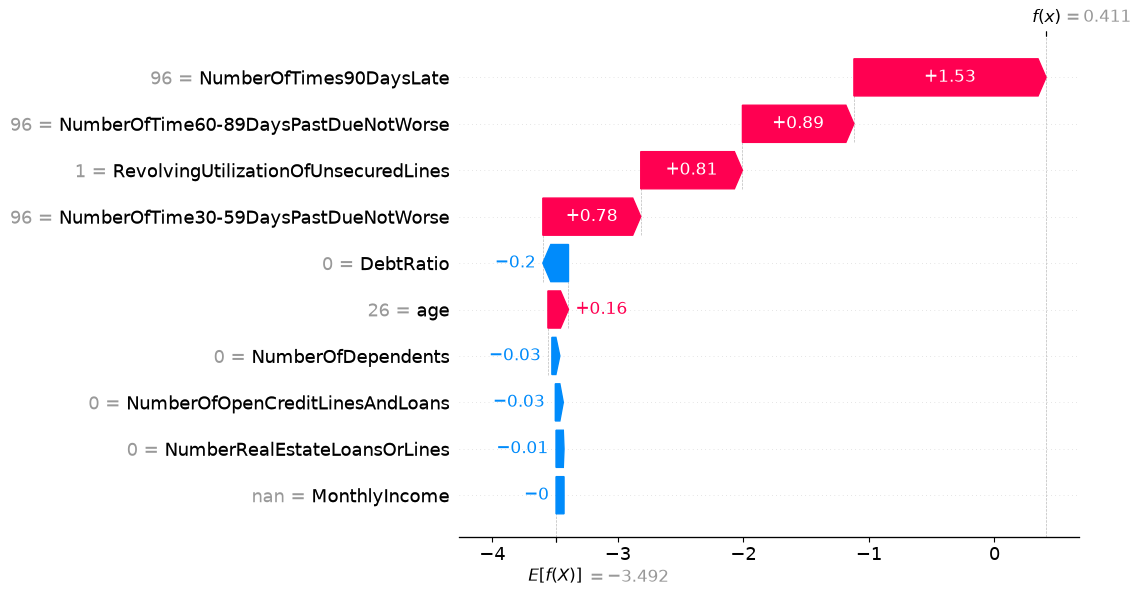

In [19]:
# Local explanation — разбор одного конкретного клиента, то, ради чего мы разбирали формулу вручную
shap.plots.waterfall(shap_values[0])

In [14]:
def explain_denial(shap_values_row, feature_names, top_k=4):
    contributions = list(zip(feature_names, shap_values_row.values))
    risk_factors = [(name, val) for name, val in contributions if val > 0]
    risk_factors.sort(key=lambda x: -x[1])
    return risk_factors[:top_k]

In [20]:
top_reasons = explain_denial(shap_values[0], X_test_clipped.columns)
top_reasons

[('NumberOfTimes90DaysLate', np.float64(1.5306282866331695)),
 ('NumberOfTime60-89DaysPastDueNotWorse', np.float64(0.8881386283190253)),
 ('RevolvingUtilizationOfUnsecuredLines', np.float64(0.8098892180567406)),
 ('NumberOfTime30-59DaysPastDueNotWorse', np.float64(0.7799095813244652))]